<div style="background:linear-gradient(135deg,#1e1b4b 0%,#4338ca 55%,#6366f1 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#c7d2fe;font-weight:700;text-transform:uppercase">Chapter 124 · Case Study: Loan Default Risk</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Case Study: Loan Default Risk</div>
  <div style="font-size:15px;color:#e0e7ff;max-width:740px;line-height:1.6">A messy real-world credit file taken end to end: parsing text-valued income and employment, engineering affordability features, comparing models, explaining every decision with SHAP for the legally-required reason codes, and auditing the model for fairness across a protected group. Library-first with scikit-learn and shap, and heavily visual.</div>
  <div style="margin-top:16px;font-size:13px;color:#c7d2fe">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

# Loan Default Risk: cleaning, explaining, and auditing a credit model
Lending is a high-stakes, regulated setting: a wrong 'approve' loses money, a wrong 'deny' harms a person, and the law demands that decisions be **explainable** and **fair**. This case study takes a deliberately messy credit file the whole way, hard **cleaning and feature engineering**, a **model comparison**, per-decision explanations with **SHAP**, and a **fairness audit** across groups. It is the most complete project in the part. Library-first with `scikit-learn` and `shap`.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, pairplots, count/bar plots)
from matplotlib.colors import ListedColormap
EM="#4338ca"; DEEP="#3730a3"; LIGHT="#c7d2fe"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; AMBER="#d97706"; GREEN="#059669"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"; ORG="#4338ca"; CYAN="#0891b2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, recall_score, precision_score
import warnings; warnings.filterwarnings('ignore'); import shap; pd.set_option('display.max_columns', 40)

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 1 &#183; DEFINE THE OBJECTIVE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Predict default, defensibly</div>
<div style="color:#4a5578;margin-top:6px">Accuracy is not enough in a regulated domain.</div>
</div>

**The goal, and its constraints.** Predict whether a loan applicant will **default**, to inform an approve/deny decision. But in lending, three things matter beyond accuracy: every decision must be **explainable** to the applicant (adverse-action notices are required by law), the model must be **fair** across protected groups, and the errors are asymmetric. We will treat the dataset's <code>group</code> column as a stand-in for a legally protected class (such as race, gender, or age), which fair-lending laws forbid discriminating on.

<div style="background:#eef6ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1d4ed8;letter-spacing:1px">STEP 2 &#183; COLLECT THE DATA</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A raw application export</div>
<div style="color:#4a5578;margin-top:6px">One row per loan application.</div>
</div>

In [3]:
try: df = pd.read_csv('../../data/loan_applications.csv')
except FileNotFoundError: df = pd.read_csv(BASE + 'loan_applications.csv')
print('raw shape:', df.shape); df.head(3)

raw shape: (5235, 13)


,application_id,group,annual_income,credit_score,employment_length,debt_to_income,revolving_util,num_credit_lines,loan_amount,home_ownership,loan_purpose,age,defaulted
0,L60207,B,"$53,096",658.0,6 years,0.317,0.675,13,18700,rent,major_purchase,32,0
1,L63345,B,"$50,109",707.0,9 years,0.370,0.483,7,25800,RENT,major_purchase,43,0
2,L60072,B,"$29,518",714.0,10+ years,0.320,0.260,8,9100,MORTGAGE,medical,32,0


<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 3 &#183; INSPECT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A genuinely messy file</div>
<div style="color:#4a5578;margin-top:6px">Text where numbers belong, and more.</div>
</div>

In [4]:
print(df.dtypes.to_string())
print('\nannual_income (should be numeric!):', df.annual_income.head(3).tolist())
print('employment_length values:', df.employment_length.value_counts().head(6).to_dict())
print('home_ownership spellings:', sorted(df.home_ownership.unique()))
print('missing credit_score:', df.credit_score.isna().sum(), '| ages under 18:', (df.age<18).sum(), '| negative DTI:', (df.debt_to_income<0).sum(), '| dup ids:', df.application_id.duplicated().sum())

application_id           str
group                    str
annual_income            str
credit_score         float64
employment_length        str
debt_to_income       float64
revolving_util       float64
num_credit_lines       int64
loan_amount            int64
home_ownership           str
loan_purpose             str
age                    int64
defaulted              int64

annual_income (should be numeric!): ['$53,096', '$50,109', '$29,518']
employment_length values: {'10+ years': 899, '4 years': 608, '3 years': 565, '5 years': 527, '2 years': 514, '6 years': 466}
home_ownership spellings: ['MORTGAGE', 'Mortgage', 'OWN', 'Own', 'RENT', 'Rent', 'mortgage', 'own', 'rent']
missing credit_score: 70 | ages under 18: 12 | negative DTI: 15 | dup ids: 35


**Real data fights back.** `annual_income` arrived as text with dollar signs and commas (and some 'n/a'); `employment_length` is free text like '10+ years' and '< 1 year'; `home_ownership` and `loan_purpose` come in mixed case and spellings; `credit_score` has gaps; and there are impossible ages and negative debt ratios, plus duplicate applications. None of this can go into a model as-is. Cleaning is not a footnote here, it is half the work.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 4 &#183; CLEAN</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Parse the text into numbers</div>
<div style="color:#4a5578;margin-top:6px">Turn a spreadsheet into a dataset.</div>
</div>

In [5]:
before = len(df)
df = df.drop_duplicates('application_id')
df['annual_income'] = pd.to_numeric(df.annual_income.str.replace(r'[$,]','',regex=True).replace('n/a', np.nan), errors='coerce')
def parse_emp(s):
    s = str(s).strip()
    if s in ('','nan'): return np.nan
    if '10+' in s: return 10.0
    if '<' in s: return 0.0
    return float(s.split()[0])
df['employment_length'] = df.employment_length.map(parse_emp)
df['home_ownership'] = df.home_ownership.str.strip().str.upper()
df['loan_purpose'] = df.loan_purpose.str.strip().str.lower().str.replace(' ','_')
df = df[df.age >= 18].copy()                          # drop impossible ages
df.loc[df.debt_to_income < 0, 'debt_to_income'] = np.nan   # negative DTI is a data error
print(f'{before} rows -> {len(df)} rows | default rate {df.defaulted.mean():.1%}')
print('home_ownership now:', sorted(df.home_ownership.unique()), '| loan_purpose now:', df.loan_purpose.nunique(), 'categories')

5235 rows -> 5188 rows | default rate 26.4%
home_ownership now: ['MORTGAGE', 'OWN', 'RENT'] | loan_purpose now: 6 categories


**From text back to numbers.** We strip the dollar formatting and coerce income to a real number, translate the employment-length phrases into years (mapping '10+' to 10 and '< 1' to 0), fold the category spellings together, and remove impossible rows and duplicates. Remaining gaps in income, credit score, and DTI are left for the pipeline to impute on training data only. After cleaning, **5,188 applications** remain, about **26% defaulted**.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 5 &#183; FEATURE ENGINEERING + EXPLORE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A ratio, and the signal</div>
<div style="color:#4a5578;margin-top:6px">Build loan-to-income, then look.</div>
</div>

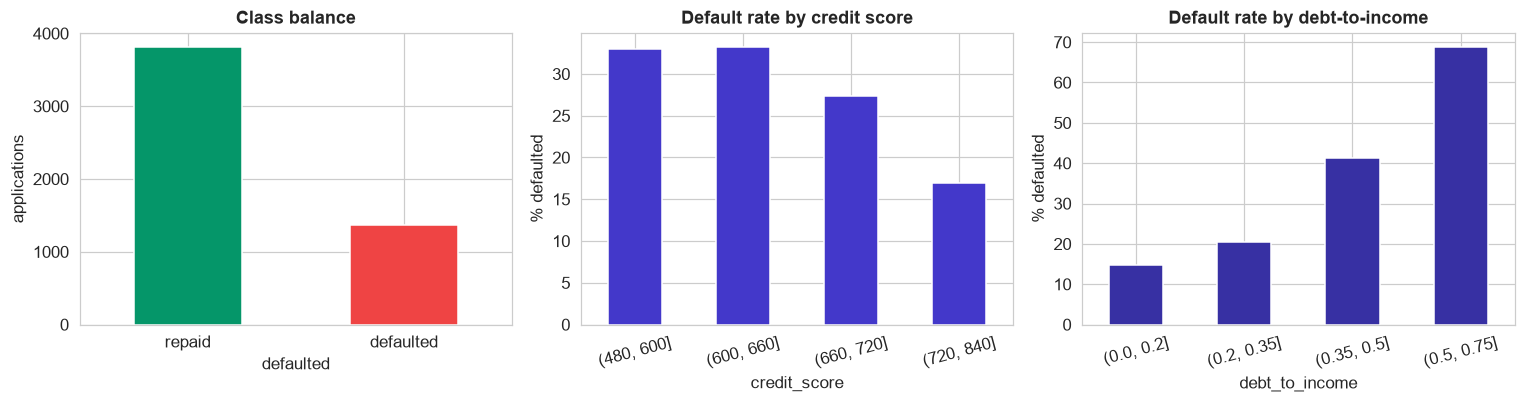

In [6]:
df['loan_to_income'] = df.loan_amount / df.annual_income.replace(0, np.nan)   # affordability, better than either alone
fig, ax = plt.subplots(1, 3, figsize=(14,3.8))
df.defaulted.value_counts().rename({0:'repaid',1:'defaulted'}).plot.bar(ax=ax[0], color=[GREEN,RED]); ax[0].set(title='Class balance', ylabel='applications'); ax[0].tick_params(axis='x', rotation=0)
df.groupby(pd.cut(df.credit_score,[480,600,660,720,840])).defaulted.mean().mul(100).plot.bar(ax=ax[1], color=EM); ax[1].set(title='Default rate by credit score', ylabel='% defaulted'); ax[1].tick_params(axis='x', rotation=15)
df.groupby(pd.cut(df.debt_to_income,[0,0.2,0.35,0.5,0.75])).defaulted.mean().mul(100).plot.bar(ax=ax[2], color=DEEP); ax[2].set(title='Default rate by debt-to-income', ylabel='% defaulted'); ax[2].tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()

**Affordability in one number.** A $20,000 loan means something very different to a $40,000 earner than to a $200,000 earner, so `loan_to_income` captures affordability better than either column alone. Exploring confirms the credit intuition: default rate falls sharply with **credit score** and rises steeply with **debt-to-income**, and both curves are clearly non-linear, a hint that a flexible model may help.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 6 &#183; SPLIT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Hold out applicants, set the protected attribute aside</div>
<div style="color:#4a5578;margin-top:6px">The model must not use `group`.</div>
</div>

In [7]:
numeric = ['annual_income','credit_score','employment_length','debt_to_income','revolving_util','num_credit_lines','loan_amount','age','loan_to_income']
categorical = ['home_ownership','loan_purpose']
X = df[numeric + categorical]; y = df['defaulted']; group = df['group']   # group is NOT a feature
X_train, X_test, y_train, y_test, g_train, g_test = train_test_split(X, y, group, test_size=0.25, random_state=0, stratify=y)
preprocess = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), numeric),
    ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical)])
print('train:', len(X_train), '| test:', len(X_test), '| group kept aside for the fairness audit, never fed to the model')

train: 3891 | test: 1297 | group kept aside for the fairness audit, never fed to the model


**Fair-through-unawareness, and its limits.** We deliberately exclude `group` from the feature set, the model never sees the protected attribute. That sounds sufficient, but Step 9 will show why it is not: other features correlate with `group`, so the model can still produce **disparate outcomes**. We keep `group` aside precisely so we can audit for that.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 7 &#183; BUILD &amp; COMPARE MODELS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Baseline, linear, and two ensembles</div>
<div style="color:#4a5578;margin-top:6px">Let cross-validation pick.</div>
</div>

baseline (predict repaid) ROC-AUC = 0.500
Logistic             ROC-AUC 0.733 | PR-AUC 0.515


Random Forest        ROC-AUC 0.731 | PR-AUC 0.518


Gradient Boosting    ROC-AUC 0.740 | PR-AUC 0.539


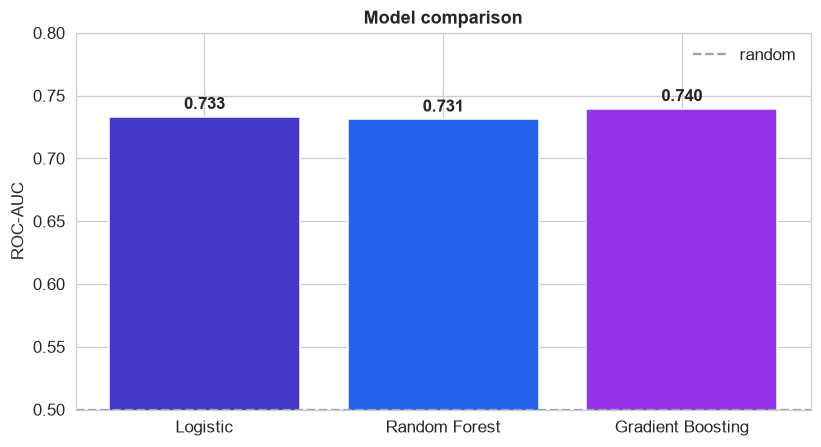

In [8]:
base = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
print('baseline (predict repaid) ROC-AUC = 0.500')
results = {}
for name, clf in [('Logistic', LogisticRegression(max_iter=3000, class_weight='balanced')),
                  ('Random Forest', RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=0)),
                  ('Gradient Boosting', GradientBoostingClassifier(random_state=0))]:
    pipe = Pipeline([('prep', preprocess), ('clf', clf)]).fit(X_train, y_train)
    prob = pipe.predict_proba(X_test)[:,1]
    results[name] = (roc_auc_score(y_test, prob), average_precision_score(y_test, prob))
    print(f'{name:20s} ROC-AUC {results[name][0]:.3f} | PR-AUC {results[name][1]:.3f}')
fig, ax = plt.subplots(figsize=(7.6,4.2))
ax.bar(results.keys(), [v[0] for v in results.values()], color=[EM, BLUE, PUR]); ax.axhline(0.5, color=GREY, ls='--', label='random')
ax.set(ylabel='ROC-AUC', title='Model comparison', ylim=(0.5,0.8)); ax.legend()
for i,v in enumerate(results.values()): ax.text(i, v[0]+0.006, f'{v[0]:.3f}', ha='center', fontweight='700')
plt.tight_layout(); plt.show()

**Here, flexibility earns its place.** Unlike the earlier chapters, the non-linear structure of credit risk (the sharp jumps at low credit scores and high debt ratios) lets **Gradient Boosting** edge ahead, ROC-AUC around **0.74** versus 0.73 for logistic regression. A credit-model AUC in the 0.70s is normal and useful; default is genuinely hard to predict. We take the gradient-boosting model forward, and because it is a tree model, **SHAP** can explain it exactly and fast.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 8 &#183; EXPLAIN WITH SHAP</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Every decision, decomposed</div>
<div style="color:#4a5578;margin-top:6px">Global drivers, and one applicant's reasons.</div>
</div>

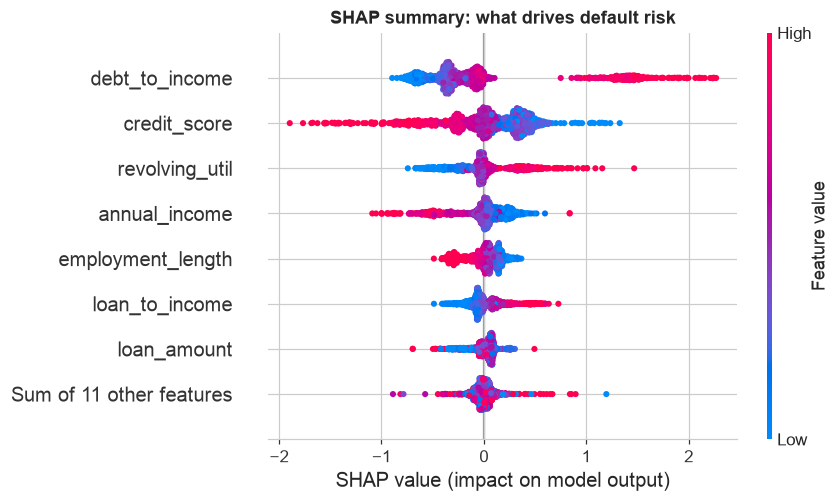

In [9]:
prep = preprocess.fit(X_train)
Xtr_t = prep.transform(X_train); Xte_t = prep.transform(X_test)
feat_names = numeric + list(prep.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical))
gbm = GradientBoostingClassifier(random_state=0).fit(Xtr_t, y_train)
explainer = shap.TreeExplainer(gbm); shap_values = explainer(Xte_t)
shap_values.feature_names = feat_names
plt.figure(); shap.plots.beeswarm(shap_values, show=False, max_display=8)
plt.title('SHAP summary: what drives default risk'); plt.tight_layout(); plt.show()

**Global explanation.** The SHAP **beeswarm** shows every applicant as a dot for each feature, colored by the feature's value (red high, blue low). The picture is exactly what a credit analyst would expect: a **high debt-to-income** ratio and **high revolving utilization** push risk up (red dots on the right), while a **high credit score** and **high income** push it down. SHAP is not decoration here, it is how the lender justifies decisions and generates the legally-required 'reason codes'.

this applicant's predicted default probability = 89%


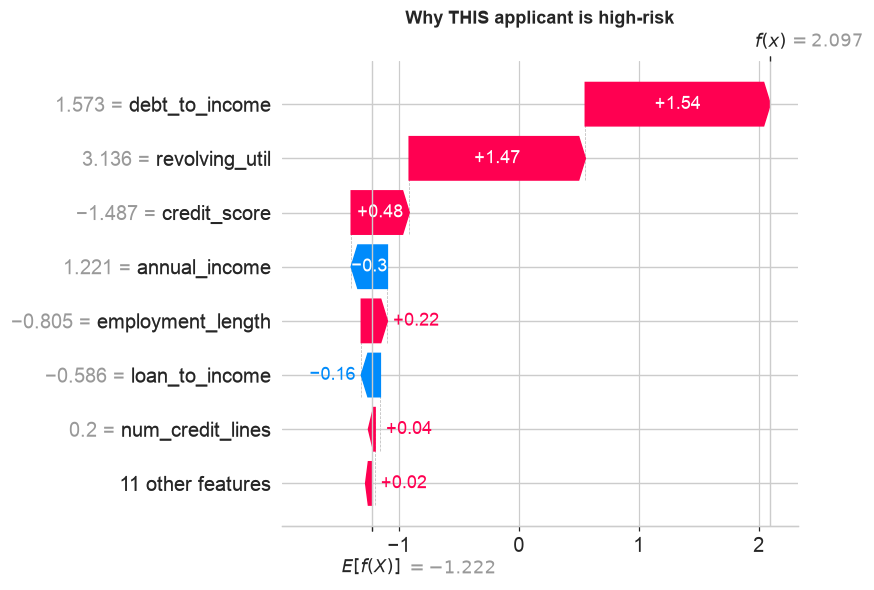

In [10]:
i = int(np.argmax(gbm.predict_proba(Xte_t)[:,1]))    # the highest-risk applicant
print('this applicant\'s predicted default probability = %.0f%%' % (gbm.predict_proba(Xte_t[[i]])[0,1]*100))
plt.figure(); shap.plots.waterfall(shap_values[i], show=False, max_display=8)
plt.title('Why THIS applicant is high-risk'); plt.tight_layout(); plt.show()

**Local explanation, the adverse-action notice.** The **waterfall** explains a single decision: starting from the average prediction, it adds each feature's push until it reaches this applicant's risk score. For the highest-risk applicant, you can read the exact reasons, a poor credit score, a stretched debt-to-income, heavy card utilization, each with its contribution. This is precisely what a bank must send a declined applicant: not 'the algorithm said no', but the specific, ranked factors behind it.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 9 &#183; FAIRNESS AUDIT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Blind is not the same as fair</div>
<div style="color:#4a5578;margin-top:6px">Measure outcomes across the protected group.</div>
</div>

         n  denial_rate  approval_rate  good_wrongly_denied
group                                                      
A      757        0.095          0.905                0.053
B      540        0.163          0.837                0.070

disparate-impact ratio (approval B / approval A): 0.93  [< 0.80 fails the four-fifths rule]
equal-opportunity gap (good applicants wrongly denied, B - A): 1.7 percentage points


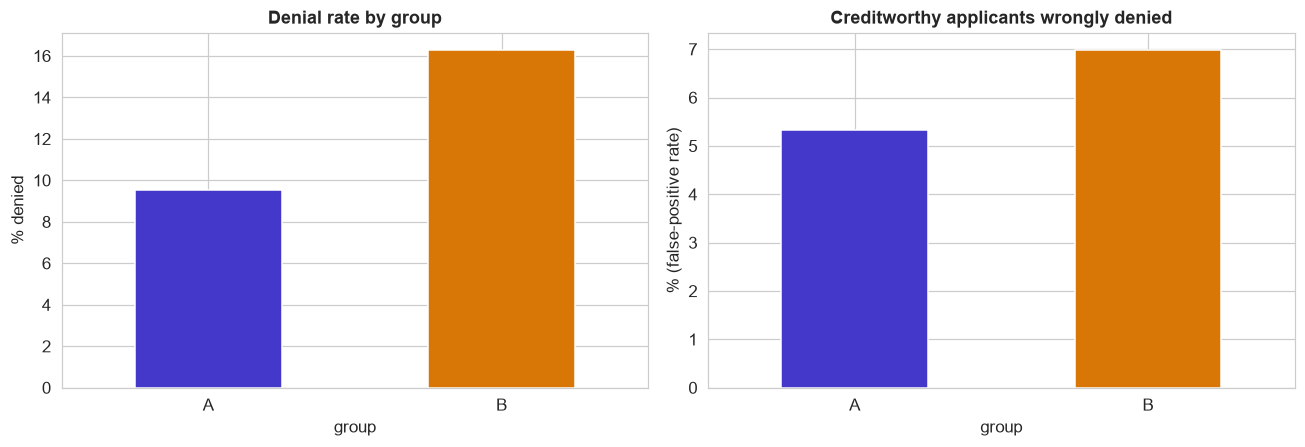

In [11]:
prob = gbm.predict_proba(Xte_t)[:,1]
DECISION = 0.5     # deny if predicted default probability >= this
audit = pd.DataFrame({'group': g_test.values, 'defaulted': y_test.values, 'deny': (prob>=DECISION).astype(int)})
rows = []
for gg in ['A','B']:
    s = audit[audit.group==gg]; good = s[s.defaulted==0]
    rows.append({'group': gg, 'n': len(s), 'denial_rate': s.deny.mean(),
        'approval_rate': 1-s.deny.mean(), 'good_wrongly_denied': good.deny.mean()})
fair = pd.DataFrame(rows).set_index('group'); print(fair.round(3).to_string())
print('\ndisparate-impact ratio (approval B / approval A): %.2f  [< 0.80 fails the four-fifths rule]' % (fair.loc['B','approval_rate']/fair.loc['A','approval_rate']))
print('equal-opportunity gap (good applicants wrongly denied, B - A): %.1f percentage points' % ((fair.loc['B','good_wrongly_denied']-fair.loc['A','good_wrongly_denied'])*100))
fig, ax = plt.subplots(1, 2, figsize=(12,4.2))
(fair.denial_rate*100).plot.bar(ax=ax[0], color=[EM,AMBER]); ax[0].set(title='Denial rate by group', ylabel='% denied'); ax[0].tick_params(axis='x', rotation=0)
(fair.good_wrongly_denied*100).plot.bar(ax=ax[1], color=[EM,AMBER]); ax[1].set(title='Creditworthy applicants wrongly denied', ylabel='% (false-positive rate)'); ax[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

**The model is blind to `group`, yet its outcomes are not equal.** Group B is denied at **16% versus 9%** for Group A, and, more tellingly, **creditworthy** Group B applicants (who would not default) are wrongly denied more often (**7% versus 5%**), an **equal-opportunity** gap. Why? Because features like income and credit history correlate with the group, disparity flows in through the back door. The approval ratio (0.93) happens to clear the legal **four-fifths rule**, but the equal-opportunity gap is a real harm a lender must confront. Mitigations include reweighting the training data, adjusting the threshold per group, or auditing features that act as proxies, and, always, measuring fairness explicitly rather than assuming that 'not using the attribute' makes a model fair.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 10 &#183; DEPLOY ON NEW DATA</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Score, explain, and monitor</div>
<div style="color:#4a5578;margin-top:6px">A decision plus its reasons.</div>
</div>

In [12]:
import joblib
final = Pipeline([('prep', preprocess), ('clf', GradientBoostingClassifier(random_state=0))]).fit(X_train, y_train)
joblib.dump(final, 'default_model.joblib'); model = joblib.load('default_model.joblib')
new_apps = pd.DataFrame([
  {'annual_income':38000,'credit_score':590,'employment_length':1,'debt_to_income':0.48,'revolving_util':0.9,'num_credit_lines':4,'loan_amount':22000,'age':29,'loan_to_income':22000/38000,'home_ownership':'RENT','loan_purpose':'debt_consolidation'},
  {'annual_income':120000,'credit_score':770,'employment_length':12,'debt_to_income':0.16,'revolving_util':0.1,'num_credit_lines':14,'loan_amount':15000,'age':47,'loan_to_income':15000/120000,'home_ownership':'MORTGAGE','loan_purpose':'home_improvement'}])
for j in range(len(new_apps)):
    p = model.predict_proba(new_apps.iloc[[j]])[0,1]
    decision = 'DENY (high risk)' if p >= DECISION else 'APPROVE'
    print(f'applicant {j+1}: default probability {p:.0%}  ->  {decision}')
print('\nin production: return a decision AND its SHAP reason codes (for the adverse-action notice),')
print('monitor fairness metrics by group on live decisions, watch for data drift, and keep a human reviewer on denials.')

applicant 1: default probability 84%  ->  DENY (high risk)
applicant 2: default probability 4%  ->  APPROVE

in production: return a decision AND its SHAP reason codes (for the adverse-action notice),
monitor fairness metrics by group on live decisions, watch for data drift, and keep a human reviewer on denials.


**A decision you can defend.** The saved pipeline scores a new application and, paired with SHAP, returns the reasons behind it, everything a compliant lending decision needs. The subprime, high-DTI applicant is denied; the high-score, low-debt applicant is approved. But deployment in a regulated domain carries extra duties beyond the earlier chapters: send **reason codes** with every denial, **monitor the fairness metrics on live decisions** (not just at build time), keep a **human in the loop** on rejections, and retrain as the economy and applicant pool shift. Chapter 126 covers operating a model like this responsibly.

## Loan default risk, in one view

1. **Cleaning was half the work**: parse text-valued income and employment, standardize categories, drop impossible rows, before any model.
2. **Feature engineering helps**: `loan_to_income` captures affordability better than loan amount or income alone.
3. **Compare models**: gradient boosting edged out logistic regression (ROC-AUC about 0.74) on this non-linear problem.
4. **Explain with SHAP**: global drivers (DTI, credit score, utilization, income) and per-applicant reason codes for the legally-required adverse-action notice.
5. **Audit fairness**: a model blind to the protected group still denied Group B more and wrongly denied creditworthy B applicants more, measure it, do not assume it away.

**In a regulated domain, a model is only as good as it is clean, explainable, and fair, not just accurate.**

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>